In [9]:
#1. Manual Histogram Equalization on a 4-bit Sample Image Matrix
import numpy as np
img = np.array([[0,1,2,3],
                [4,5,6,7],
                [8,9,10,11],
                [12,13,14,15]])

L = 16
hist = np.zeros(L, int)

for i in img.flatten():
    hist[i] += 1

cdf = np.cumsum(hist) / img.size
result = np.floor((L-1) * cdf).astype(int)[img]

print("Original Image:\n", img)
print("\nHistogram:\n", hist)
print("\nEqualized Image:\n", result)

Original Image:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]

Histogram:
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]

Equalized Image:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]
 [12 13 14 15]]


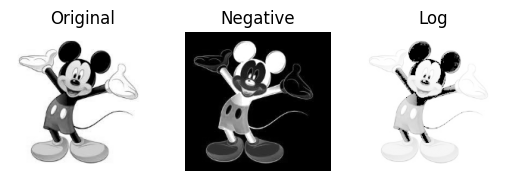

In [10]:
#2. Implementing Negative and Log Transformations on a Grayscale Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-02-26 140552.png", 0)

negative = 255 - img
log = np.uint8(255 * np.log1p(img) / np.log1p(255))

plt.subplot(131)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(132)
plt.imshow(negative, cmap="gray")
plt.title("Negative")
plt.axis("off")

plt.subplot(133)
plt.imshow(log, cmap="gray")
plt.title("Log")
plt.axis("off")

plt.show()

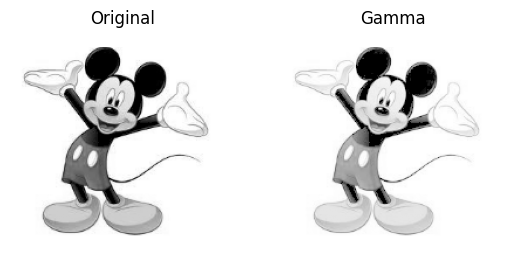

In [11]:
# 3. Power-Law (Gamma) Transformation: Effect of Varying Gamma on Contrast
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-02-26 140552.png", 0)

gamma = 0.5
result = np.uint8(255 * (img / 255) ** gamma)

plt.subplot(121)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(result, cmap="gray")
plt.title("Gamma")
plt.axis("off")

plt.show()

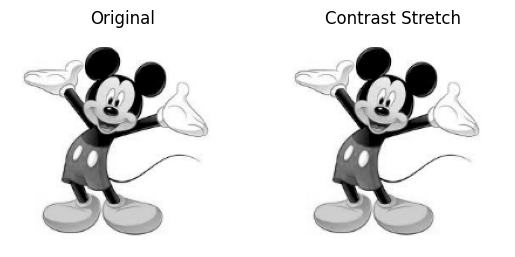

In [12]:
#4. Piecewise-Linear Contrast Stretching of a Low-Contrast Image
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-02-26 140552.png", 0)

result = np.interp(img, (img.min(), img.max()), (0, 255)).astype(np.uint8)

plt.subplot(121)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(result, cmap="gray")
plt.title("Contrast Stretch")
plt.axis("off")

plt.show()

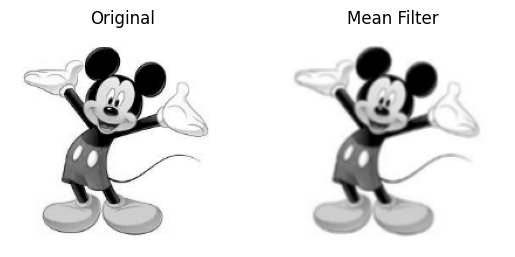

In [13]:
#5. Mean (Averaging) Filter: Kernel Convolution on a Sample 5x5 Matrix
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-02-26 140552.png", 0)

result = cv2.blur(img, (3,3))

plt.subplot(121)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(result, cmap="gray")
plt.title("Mean Filter")
plt.axis("off")

plt.show()

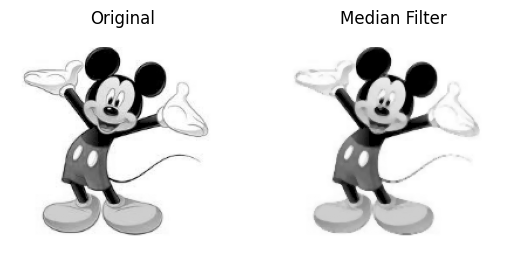

In [14]:
# 6. Median Filter for Salt-and-Pepper Noise Removal - Quantitative Comparison
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-02-26 140552.png", 0)

result = cv2.medianBlur(img, 3)

plt.subplot(121)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(result, cmap="gray")
plt.title("Median Filter")
plt.axis("off")

plt.show()

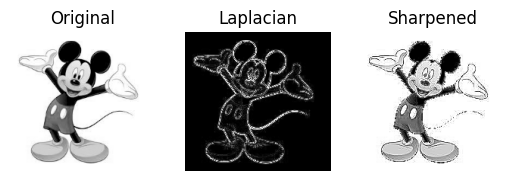

In [15]:
# 7. Sharpening Using the Laplacian Operator on a Sample Image
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-02-26 140552.png", 0)

lap = cv2.Laplacian(img, cv2.CV_64F)
sharp = cv2.convertScaleAbs(img - lap)

plt.subplot(131)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(132)
plt.imshow(cv2.convertScaleAbs(lap), cmap="gray")
plt.title("Laplacian")
plt.axis("off")

plt.subplot(133)
plt.imshow(sharp, cmap="gray")
plt.title("Sharpened")
plt.axis("off")

plt.show()

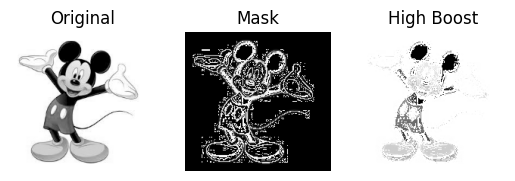

In [16]:
#8. High-Boost Filtering: Deriving the Output for a Given Boost Factor

import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-02-26 140552.png", 0)

blur = cv2.GaussianBlur(img, (5,5), 0)
mask = img - blur
result = cv2.addWeighted(img, 1, mask, 2, 0)

plt.subplot(131)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(132)
plt.imshow(mask, cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.subplot(133)
plt.imshow(result, cmap="gray")
plt.title("High Boost")
plt.axis("off")

plt.show()

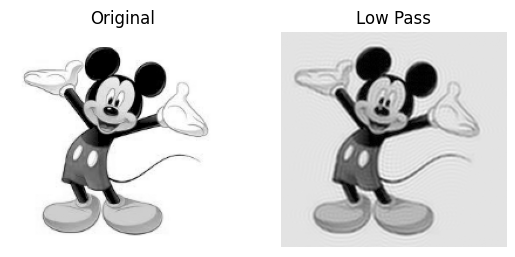

In [17]:
# 9. Frequency-Domain Low-Pass Filtering Using an Ideal Filter — Cut-off Frequency analysis
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-02-26 140552.png", 0)

f = np.fft.fft2(img)
fshift = np.fft.fftshift(f)

rows, cols = img.shape
mask = np.zeros((rows, cols), np.uint8)
crow, ccol = rows//2, cols//2
r = 50
mask[crow-r:crow+r, ccol-r:ccol+r] = 1

fshift = fshift * mask
img_back = np.fft.ifft2(np.fft.ifftshift(fshift))
img_back = np.abs(img_back)

plt.subplot(121)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(img_back, cmap="gray")
plt.title("Low Pass")
plt.axis("off")

plt.show()

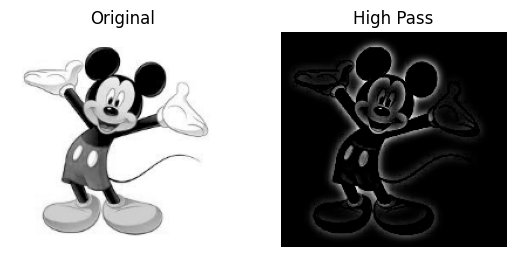

In [18]:
# 10. Frequency-Domain High-Pass Filtering - Edge Emphasis Using a Gaussian HPF

import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-02-26 140552.png", 0)

blur = cv2.GaussianBlur(img, (21,21), 0)
result = cv2.subtract(img, blur)

plt.subplot(121)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(result, cmap="gray")
plt.title("High Pass")
plt.axis("off")

plt.show()

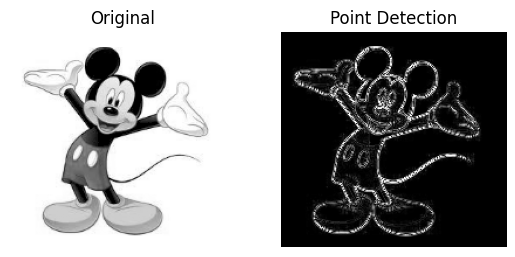

In [19]:
# 11. Point Detection Using a Laplacian-Based Mask on a Synthetic Image
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-02-26 140552.png",0)

lap = cv2.Laplacian(img, cv2.CV_64F)
result = cv2.convertScaleAbs(lap)

plt.subplot(121)
plt.imshow(img,cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(result,cmap="gray")
plt.title("Point Detection")
plt.axis("off")

plt.show()

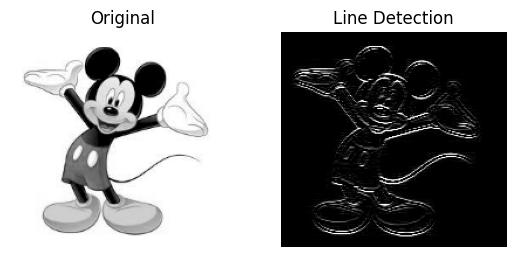

In [20]:
# 12. Line Detection Using Directional Masks
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-02-26 140552.png",0)

kernel = np.array([[-1,-1,-1],
                   [ 2, 2, 2],
                   [-1,-1,-1]])

result = cv2.filter2D(img,-1,kernel)

plt.subplot(121)
plt.imshow(img,cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(result,cmap="gray")
plt.title("Line Detection")
plt.axis("off")

plt.show()

Threshold Value: 149.0


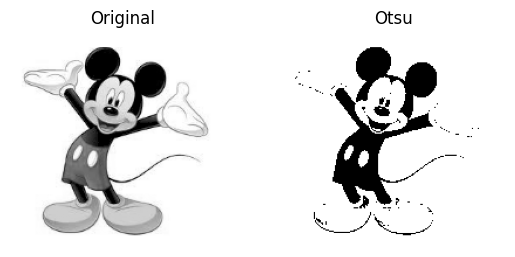

In [21]:
# 13. Global Thresholding via Otsu's Method - Numeric Computation
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-02-26 140552.png",0)

t,result = cv2.threshold(img,0,255,cv2.THRESH_BINARY+cv2.THRESH_OTSU)

print("Threshold Value:",t)

plt.subplot(121)
plt.imshow(img,cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(result,cmap="gray")
plt.title("Otsu")
plt.axis("off")

plt.show()

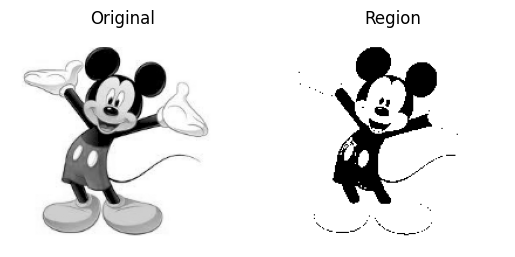

In [22]:
# 14. Region-Growing Segmentation from a Given Seed Pixel
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-02-26 140552.png",0)

result = cv2.threshold(img,127,255,cv2.THRESH_BINARY)[1]

plt.subplot(121)
plt.imshow(img,cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(122)
plt.imshow(result,cmap="gray")
plt.title("Region")
plt.axis("off")

plt.show()

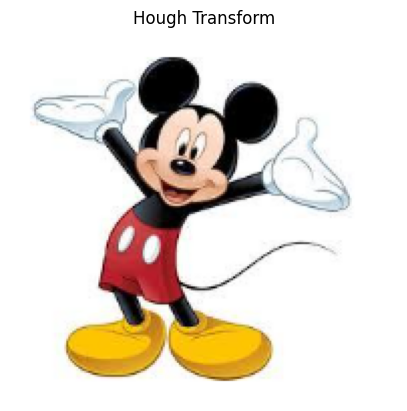

In [23]:
# 15. Edge Linking via the Hough-Based Local Processing Approach
import cv2
import matplotlib.pyplot as plt

img = cv2.imread("/content/Screenshot 2026-02-26 140552.png")
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray,50,150)

lines = cv2.HoughLinesP(edges,1,3.14/180,100,minLineLength=50,maxLineGap=10)

if lines is not None:
    for line in lines:
        x1,y1,x2,y2 = line[0]
        cv2.line(img,(x1,y1),(x2,y2),(0,255,0),2)

plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))
plt.title("Hough Transform")
plt.axis("off")
plt.show()